In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('ecommerce_customer_churn_dataset.csv')

In [3]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [4]:
df.shape

(50000, 25)

In [5]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [7]:
df.dtypes

Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

In [8]:
df.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [9]:
df.duplicated().sum()   

np.int64(0)

In [10]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [11]:
# Dropping columns with low predictive value

df = df.drop(columns=[
    'Country',      # High cardinality location feature
    'City',         # Too many unique values, noisy feature
    'Signup_Quarter' # Weak signal for churn prediction
])

In [12]:
null_cols = df.columns[df.isnull().any()]

df[null_cols].dtypes

Age                              float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Wishlist_Items                   float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Credit_Balance                   float64
dtype: object

In [13]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [14]:
df.isnull().sum()

Age                              0
Gender                           0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
dtype: int64

In [15]:
df.head()

,Age,Gender,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,...,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0
1,36.0,Male,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,...,9.2,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0
2,45.0,Female,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,...,11.5,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0
3,56.0,Female,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,...,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0
4,35.0,Male,3.1,29.0,51.4,8.4,19.1,9.0,32.5,141.30,...,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0


In [16]:
df.nunique()

Age                                 62
Gender                               3
Membership_Years                   200
Login_Frequency                     46
Session_Duration_Avg               658
Pages_Per_Session                  224
Cart_Abandonment_Rate             1000
Wishlist_Items                      25
Total_Purchases                    150
Average_Order_Value              16407
Days_Since_Last_Purchase           235
Discount_Usage_Rate               1727
Returns_Rate                       394
Email_Open_Rate                    720
Customer_Service_Calls              21
Product_Reviews_Written             18
Social_Media_Engagement_Score      972
Mobile_App_Usage                   540
Payment_Method_Diversity             5
Lifetime_Value                   45447
Credit_Balance                    5234
Churned                              2
dtype: int64

In [17]:
for col in df.columns:
    print("\n", col)
    print(df[col].value_counts())


 Age
Age
38.0     4133
18.0     2639
37.0     1627
40.0     1570
39.0     1564
         ... 
5.0        16
10.0       14
74.0       11
200.0      11
150.0       9
Name: count, Length: 62, dtype: int64

 Gender
Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64

 Membership_Years
Membership_Years
1.400000    1252
1.600000    1244
1.800000    1221
1.300000    1217
1.500000    1215
            ... 
0.256673       1
0.356012       1
0.247508       1
0.309915       1
0.368402       1
Name: count, Length: 200, dtype: int64

 Login_Frequency
Login_Frequency
0.0     4030
8.0     2466
11.0    2463
9.0     2449
10.0    2377
12.0    2330
14.0    2259
7.0     2251
6.0     2207
13.0    2181
5.0     2035
15.0    2012
16.0    1859
4.0     1804
17.0    1704
3.0     1650
18.0    1570
19.0    1463
2.0     1432
20.0    1328
1.0     1240
21.0    1109
22.0     979
23.0     866
24.0     740
25.0     644
26.0     488
27.0     428
28.0     346
29.0     287
30.0     229
31.0     

In [18]:
df['Churned'].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [19]:
df

,Age,Gender,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
0,43.0,Male,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,...,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0
1,36.0,Male,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,...,9.2,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0
2,45.0,Female,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,...,11.5,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0
3,56.0,Female,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,...,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0
4,35.0,Male,3.1,29.0,51.4,8.4,19.1,9.0,32.5,141.30,...,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,10.0,10.0,35.8,8.8,51.2,3.0,13.0,156.76,...,5.4,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0
49996,37.0,Male,1.4,21.0,32.4,9.6,32.5,2.0,15.0,103.31,...,5.4,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0
49997,44.0,Female,2.8,19.0,40.3,10.4,50.6,1.0,12.0,139.44,...,10.7,25.2,4.0,6.0,59.9,18.6,1.0,1655.28,1622.0,0
49998,41.0,Female,2.9,17.0,29.9,10.1,60.8,1.0,12.0,111.58,...,2.5,34.6,5.0,2.0,27.6,14.1,3.0,1286.11,2634.0,0


In [20]:
df.isnull().sum()   

Age                              0
Gender                           0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
dtype: int64

In [21]:
df.dtypes

Age                              float64
Gender                            object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
dtype: object

In [22]:
int_columns = [
    'Age',
    'Wishlist_Items',
    'Total_Purchases',
    'Days_Since_Last_Purchase',
    'Customer_Service_Calls',
    'Product_Reviews_Written',
    'Payment_Method_Diversity'
]

df[int_columns] = df[int_columns].astype(int)

In [23]:
df['Gender'] = df['Gender'].astype('category')

In [24]:
df.dtypes

Age                                 int64
Gender                           category
Membership_Years                  float64
Login_Frequency                   float64
Session_Duration_Avg              float64
Pages_Per_Session                 float64
Cart_Abandonment_Rate             float64
Wishlist_Items                      int64
Total_Purchases                     int64
Average_Order_Value               float64
Days_Since_Last_Purchase            int64
Discount_Usage_Rate               float64
Returns_Rate                      float64
Email_Open_Rate                   float64
Customer_Service_Calls              int64
Product_Reviews_Written             int64
Social_Media_Engagement_Score     float64
Mobile_App_Usage                  float64
Payment_Method_Diversity            int64
Lifetime_Value                    float64
Credit_Balance                    float64
Churned                             int64
dtype: object

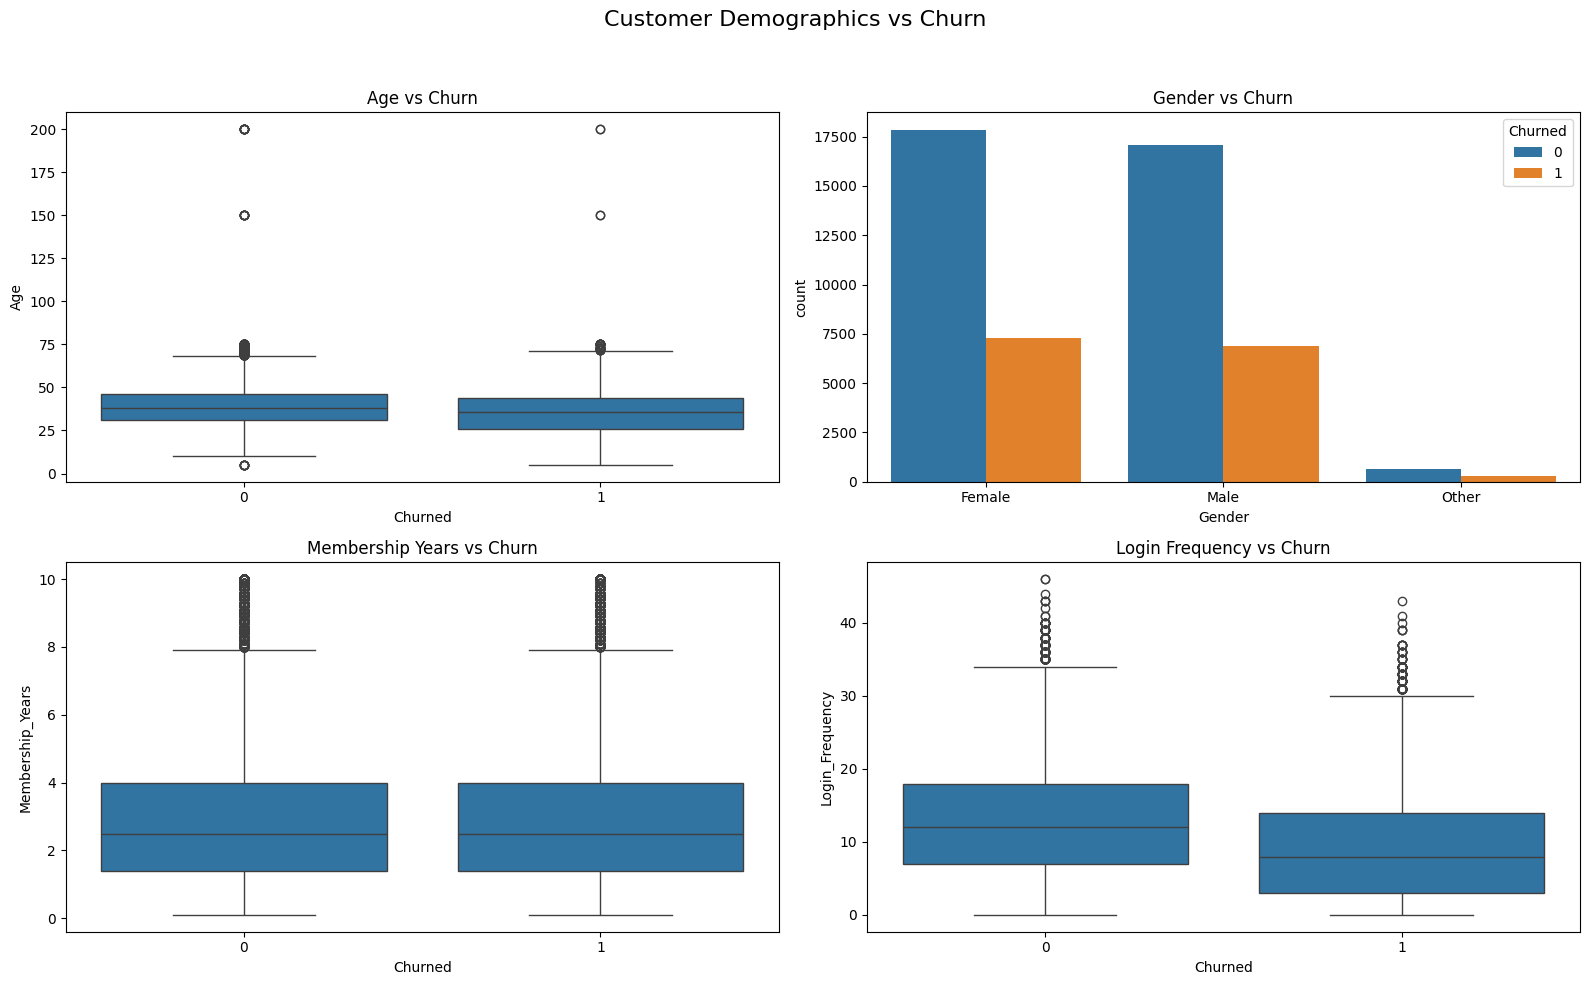

In [25]:
plt.figure(figsize=(16,10))
plt.suptitle("Customer Demographics vs Churn", fontsize=16)

# Age vs Churn
plt.subplot(2,2,1)
sns.boxplot(x='Churned', y='Age', data=df)
plt.title("Age vs Churn")

# Gender vs Churn
plt.subplot(2,2,2)
sns.countplot(x='Gender', hue='Churned', data=df)
plt.title("Gender vs Churn")

# Membership Years vs Churn
plt.subplot(2,2,3)
sns.boxplot(x='Churned', y='Membership_Years', data=df)
plt.title("Membership Years vs Churn")

# Login Frequency vs Churn
plt.subplot(2,2,4)
sns.boxplot(x='Churned', y='Login_Frequency', data=df)
plt.title("Login Frequency vs Churn")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

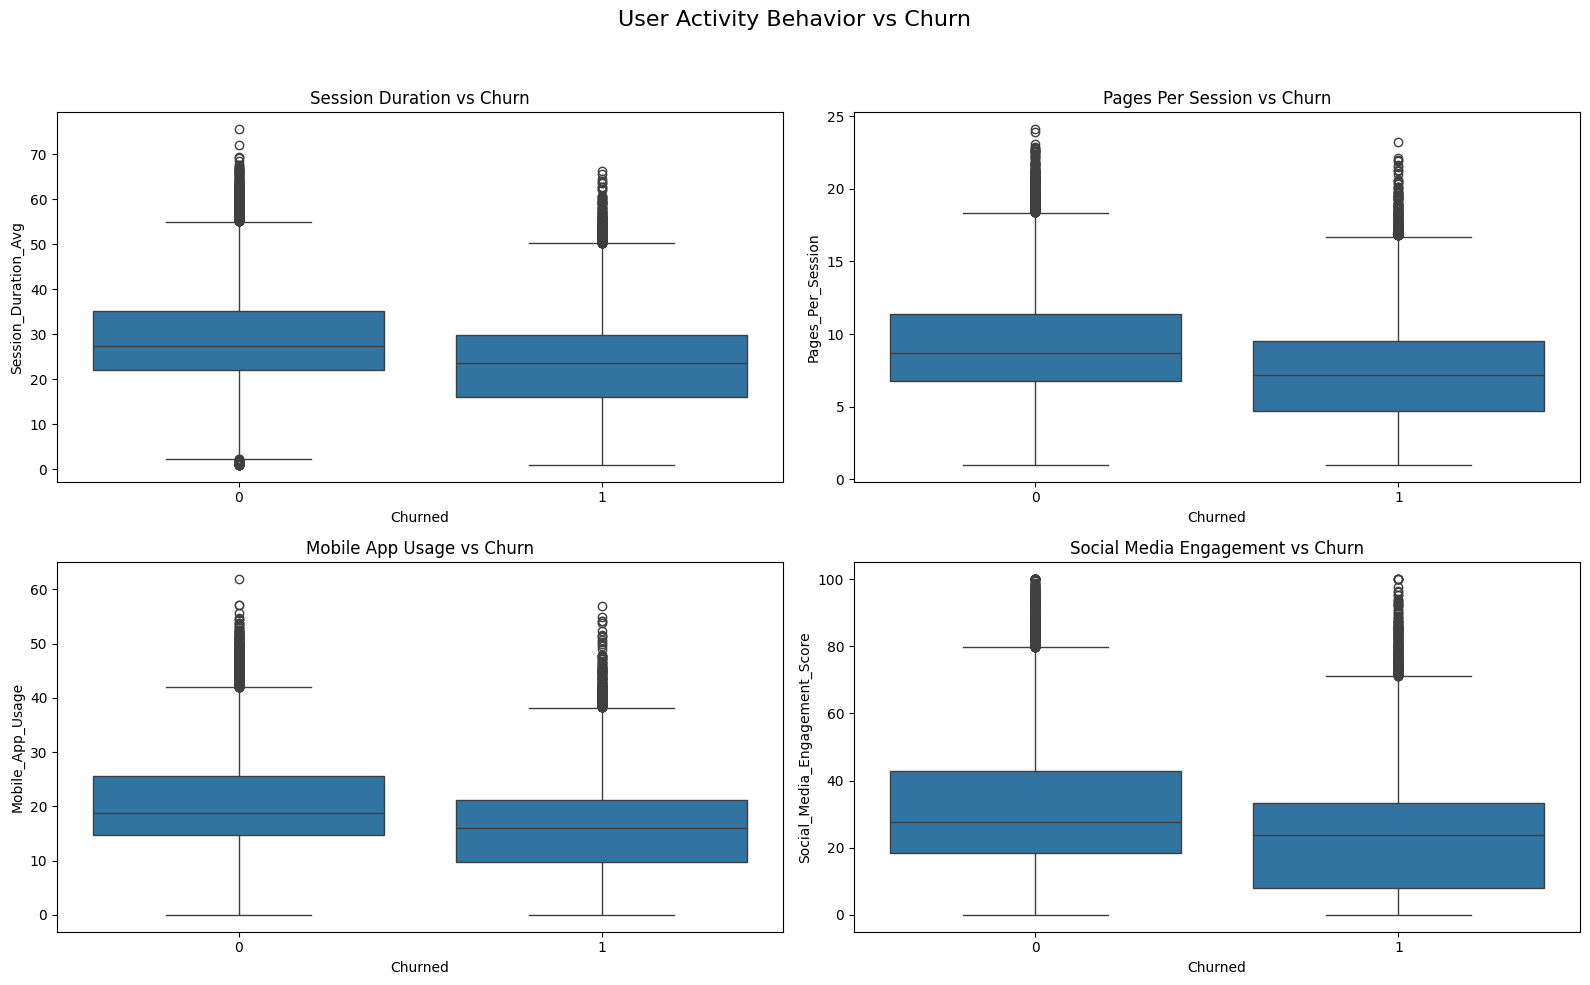

In [26]:
plt.figure(figsize=(16,10))
plt.suptitle("User Activity Behavior vs Churn", fontsize=16)

# Session Duration
plt.subplot(2,2,1)
sns.boxplot(x='Churned', y='Session_Duration_Avg', data=df)
plt.title("Session Duration vs Churn")

# Pages Per Session
plt.subplot(2,2,2)
sns.boxplot(x='Churned', y='Pages_Per_Session', data=df)
plt.title("Pages Per Session vs Churn")

# Mobile App Usage
plt.subplot(2,2,3)
sns.boxplot(x='Churned', y='Mobile_App_Usage', data=df)
plt.title("Mobile App Usage vs Churn")

# Social Media Engagement
plt.subplot(2,2,4)
sns.boxplot(x='Churned', y='Social_Media_Engagement_Score', data=df)
plt.title("Social Media Engagement vs Churn")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

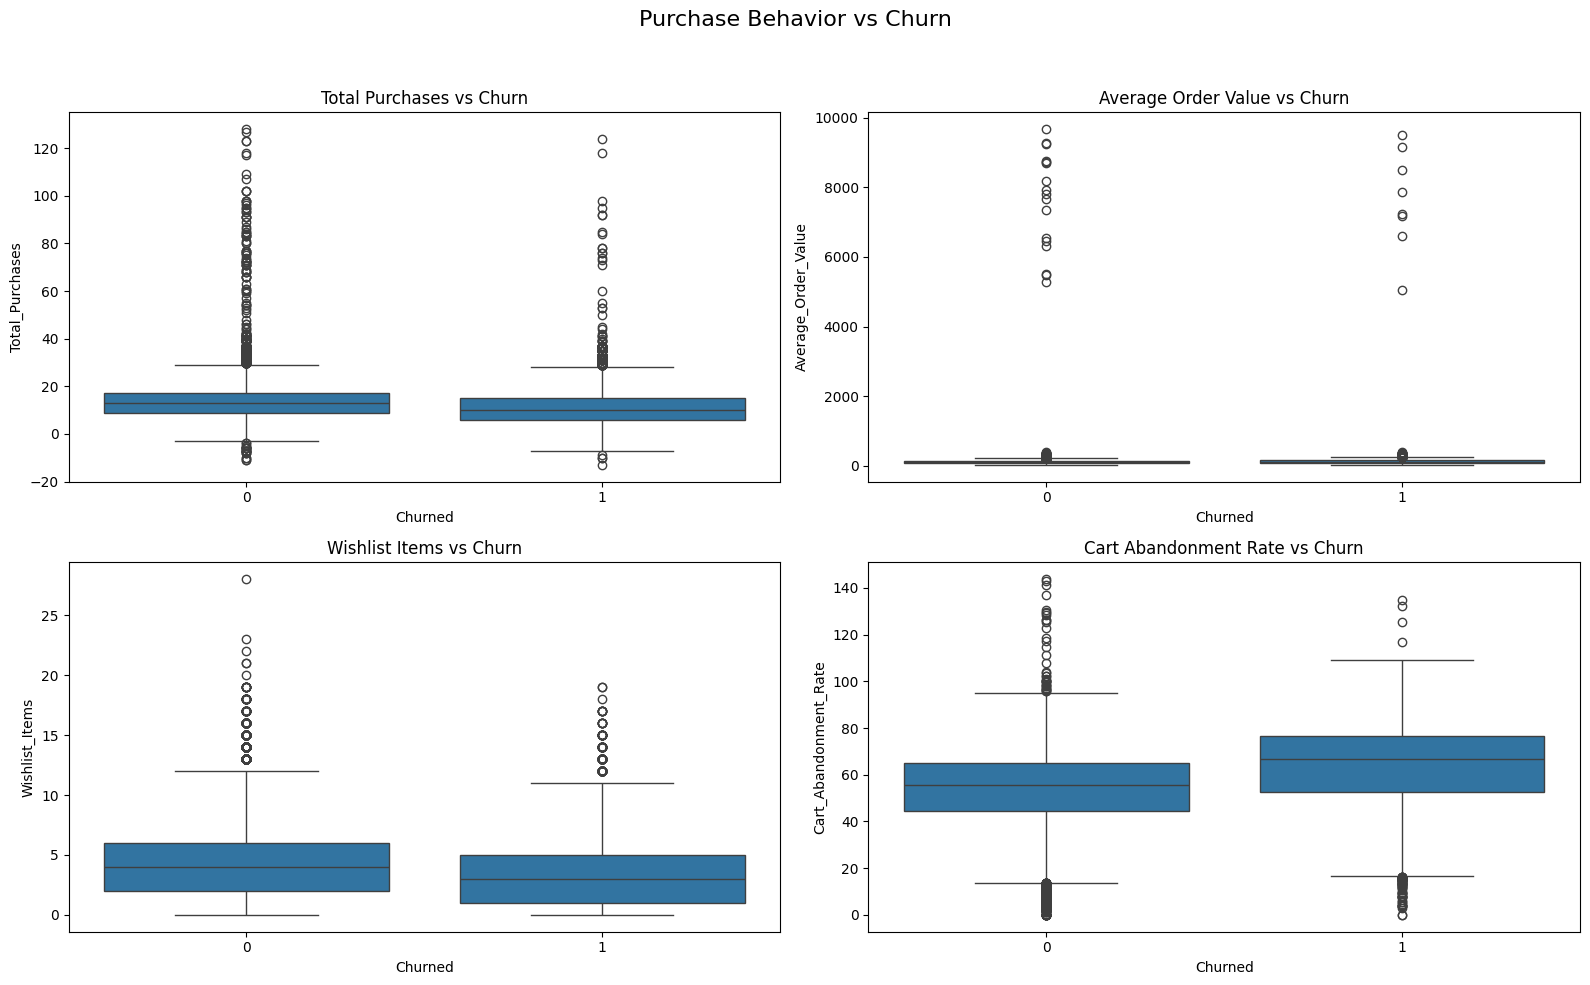

In [27]:
plt.figure(figsize=(16,10))
plt.suptitle("Purchase Behavior vs Churn", fontsize=16)

# Total Purchases
plt.subplot(2,2,1)
sns.boxplot(x='Churned', y='Total_Purchases', data=df)
plt.title("Total Purchases vs Churn")

# Average Order Value
plt.subplot(2,2,2)
sns.boxplot(x='Churned', y='Average_Order_Value', data=df)
plt.title("Average Order Value vs Churn")

# Wishlist Items
plt.subplot(2,2,3)
sns.boxplot(x='Churned', y='Wishlist_Items', data=df)
plt.title("Wishlist Items vs Churn")

# Cart Abandonment
plt.subplot(2,2,4)
sns.boxplot(x='Churned', y='Cart_Abandonment_Rate', data=df)
plt.title("Cart Abandonment Rate vs Churn")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [28]:
df['Age'].unique()

array([ 43,  36,  45,  56,  35,  47,  32,  44,  40,  18,  31,  25,  41,
        27,  21,  55,  38,  20,  39,  42,  30,  34,  60,  37,  23,  22,
        46,  29,  50,  33,  49,  24,  54,  28,  48,  67,  51,  64,  26,
        19,  53,  70,  75,  65,  63,  59,  57,  52,  62,  61,  74,  58,
        68,   5,  69,  66,  71,  73,  10,  72, 150, 200])

In [29]:
df['Credit_Balance'].describe()

count    50000.000000
mean      1958.507600
std       1155.938248
min          0.000000
25%       1164.000000
50%       1896.000000
75%       2664.000000
max       7197.000000
Name: Credit_Balance, dtype: float64

In [30]:
df['Membership_Years'].unique()

array([ 2.9       ,  1.6       ,  2.6       ,  3.1       ,  3.5       ,
        1.9       ,  1.3       ,  3.6       ,  0.9       ,  0.6       ,
        7.1       ,  3.7       ,  1.4       ,  0.7       ,  2.        ,
        5.6       ,  1.2       ,  4.7       ,  2.7       ,  3.3       ,
        3.9       ,  0.4       ,  4.4       ,  5.4       ,  4.9       ,
        7.5       ,  2.1       ,  1.5       ,  3.2       ,  2.2       ,
        5.        ,  0.5       ,  3.        ,  6.        ,  1.7       ,
        0.8       ,  4.8       ,  1.8       ,  6.3       ,  0.3       ,
        4.        ,  3.8       ,  4.3       ,  9.3       ,  5.3       ,
        0.2       ,  3.4       ,  2.5       ,  2.3       ,  2.8       ,
        6.6       ,  7.7       ,  4.1       ,  9.1       ,  1.        ,
        1.1       ,  7.4       ,  0.1       ,  9.5       ,  5.2       ,
        4.5       ,  4.6       ,  2.4       ,  5.7       ,  6.7       ,
        8.1       , 10.        ,  6.1       ,  9.        ,  6.5 

In [31]:
df['Cart_Abandonment_Rate'].describe()

count    50000.000000
mean        57.079973
std         16.282723
min          0.000000
25%         46.400000
50%         58.100000
75%         68.700000
max        143.743350
Name: Cart_Abandonment_Rate, dtype: float64

In [32]:
df = df[(df['Age'] >= 15) & (df['Age'] <= 90)]

In [33]:
df = df[(df['Age'] >= 15) & (df['Age'] <= 90)]

In [34]:
df['Cart_Abandonment_Rate'] = df['Cart_Abandonment_Rate'].clip(upper=100)

In [35]:
df[['Age','Cart_Abandonment_Rate','Credit_Balance']].describe()

,Age,Cart_Abandonment_Rate,Credit_Balance
count,49950.000000,49950.000000,49950.000000
mean,37.775175,57.065926,1958.685526
std,11.161606,16.240360,1155.830663
min,18.000000,0.000000,0.000000
25%,30.000000,46.400000,1164.000000
50%,38.000000,58.100000,1896.000000
75%,45.000000,68.700000,2664.000000
max,75.000000,100.000000,7197.000000


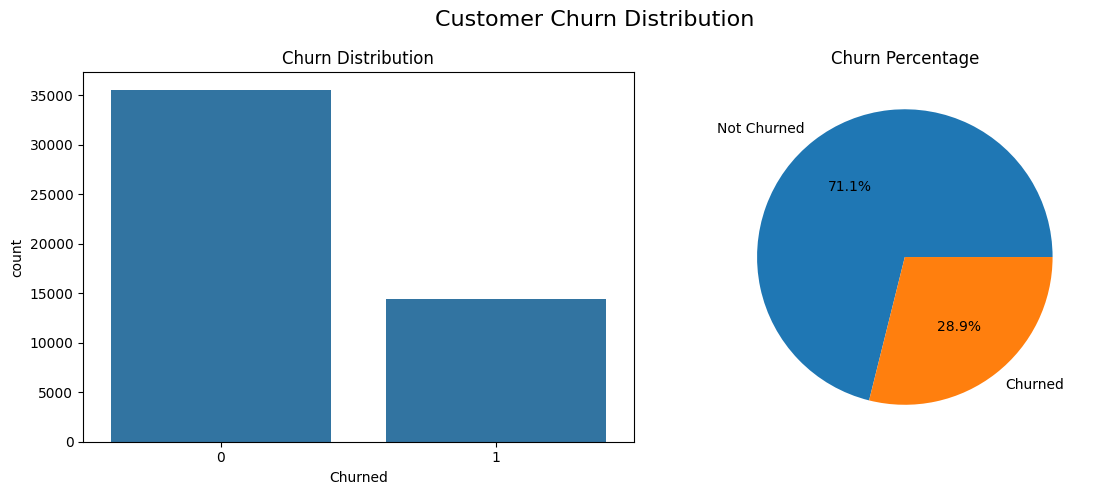

In [36]:
plt.figure(figsize=(12,5))

plt.suptitle("Customer Churn Distribution", fontsize=16)

# Countplot
plt.subplot(1,2,1)
sns.countplot(x='Churned', data=df)
plt.title("Churn Distribution")

# Pie Chart
plt.subplot(1,2,2)
df['Churned'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Not Churned','Churned']
)
plt.title("Churn Percentage")
plt.ylabel("")

plt.tight_layout()
plt.show()

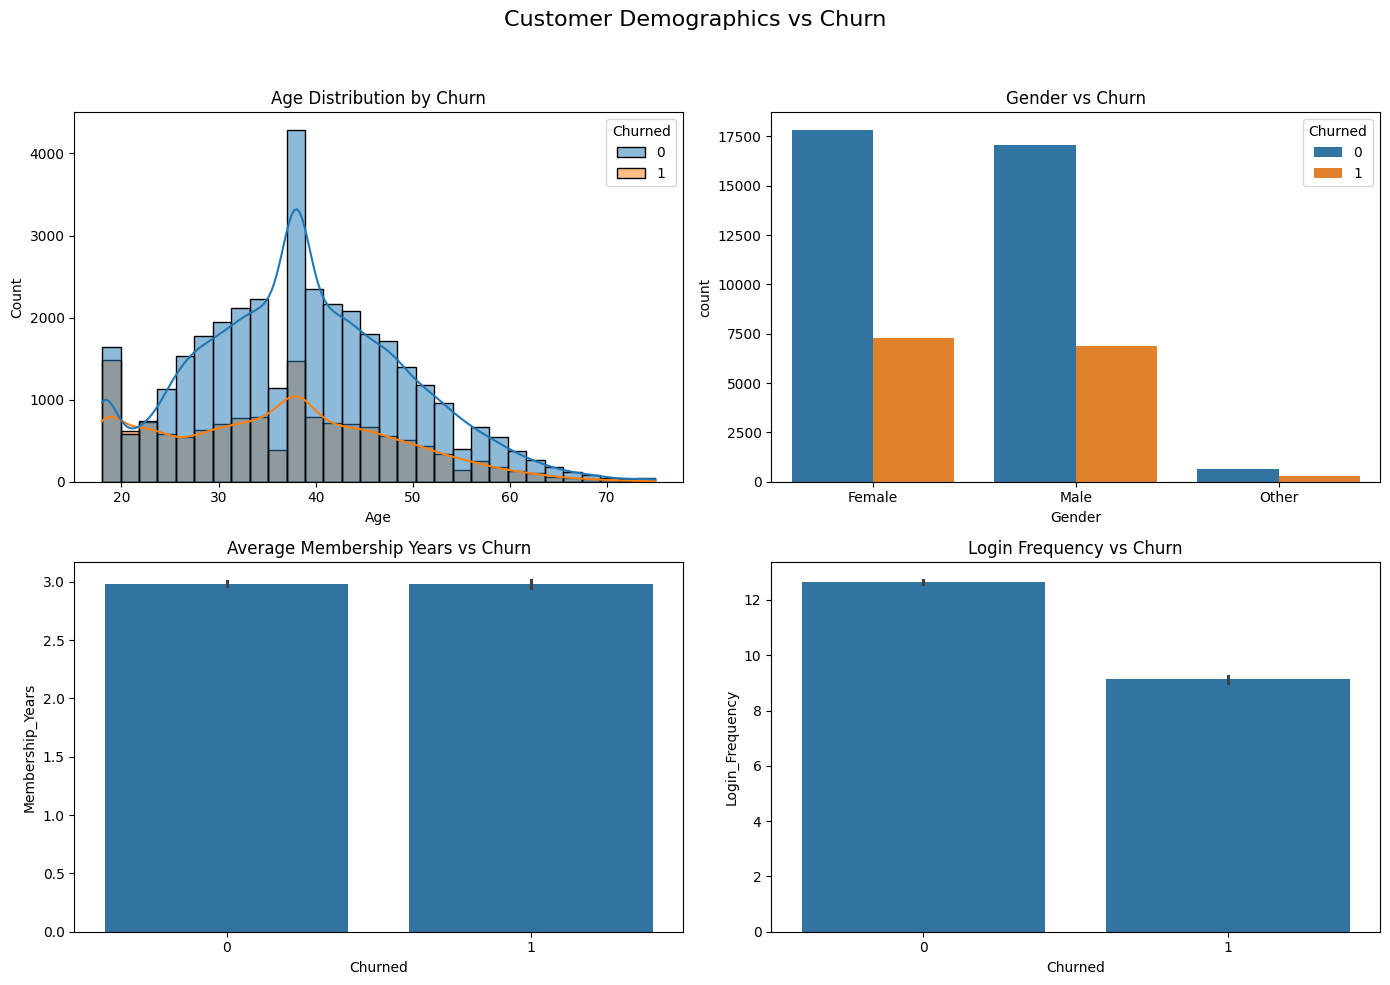

In [37]:
plt.figure(figsize=(14,10))
plt.suptitle("Customer Demographics vs Churn", fontsize=16)

# Age Distribution
plt.subplot(2,2,1)
sns.histplot(data=df, x='Age', hue='Churned', bins=30, kde=True)
plt.title("Age Distribution by Churn")

# Gender vs Churn
plt.subplot(2,2,2)
sns.countplot(x='Gender', hue='Churned', data=df)
plt.title("Gender vs Churn")

# Membership Years vs Churn (REPLACED)
plt.subplot(2,2,3)
sns.barplot(x='Churned', y='Membership_Years', data=df)
plt.title("Average Membership Years vs Churn")

# Login Frequency
plt.subplot(2,2,4)
sns.barplot(x='Churned', y='Login_Frequency', data=df)
plt.title("Login Frequency vs Churn")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

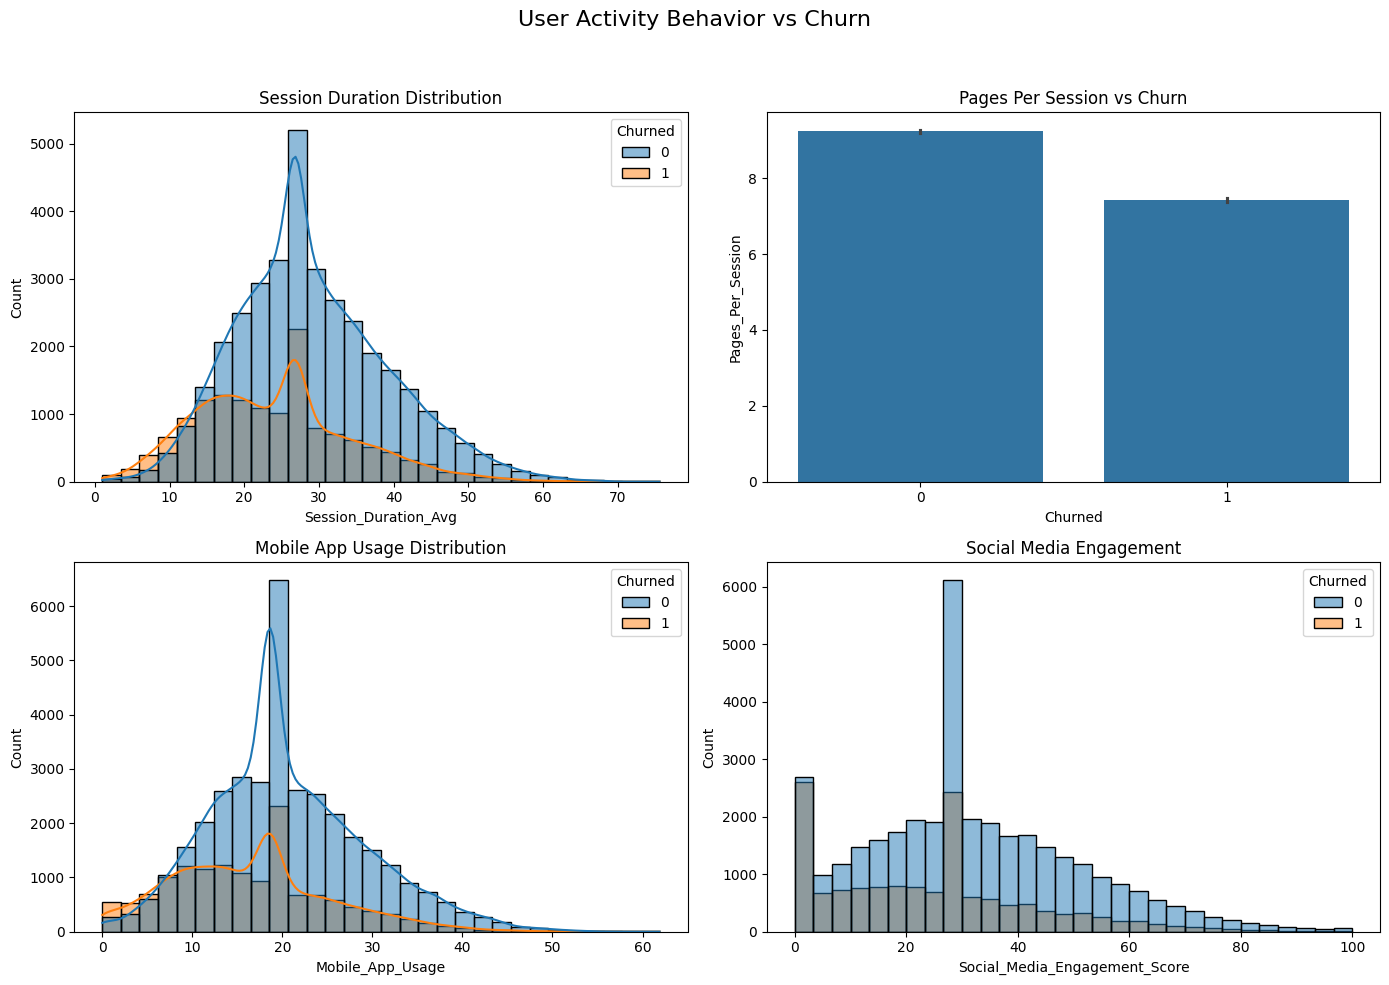

In [38]:
plt.figure(figsize=(14,10))
plt.suptitle("User Activity Behavior vs Churn", fontsize=16)

# Session Duration
plt.subplot(2,2,1)
sns.histplot(data=df, x='Session_Duration_Avg', hue='Churned', bins=30, kde=True)
plt.title("Session Duration Distribution")

# Pages Per Session
plt.subplot(2,2,2)
sns.barplot(x='Churned', y='Pages_Per_Session', data=df)
plt.title("Pages Per Session vs Churn")

# Mobile App Usage
plt.subplot(2,2,3)
sns.histplot(data=df, x='Mobile_App_Usage', hue='Churned', bins=30, kde=True)
plt.title("Mobile App Usage Distribution")

# Social Media Engagement
plt.subplot(2,2,4)
sns.histplot(data=df, x='Social_Media_Engagement_Score', hue='Churned', bins=30)
plt.title("Social Media Engagement")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

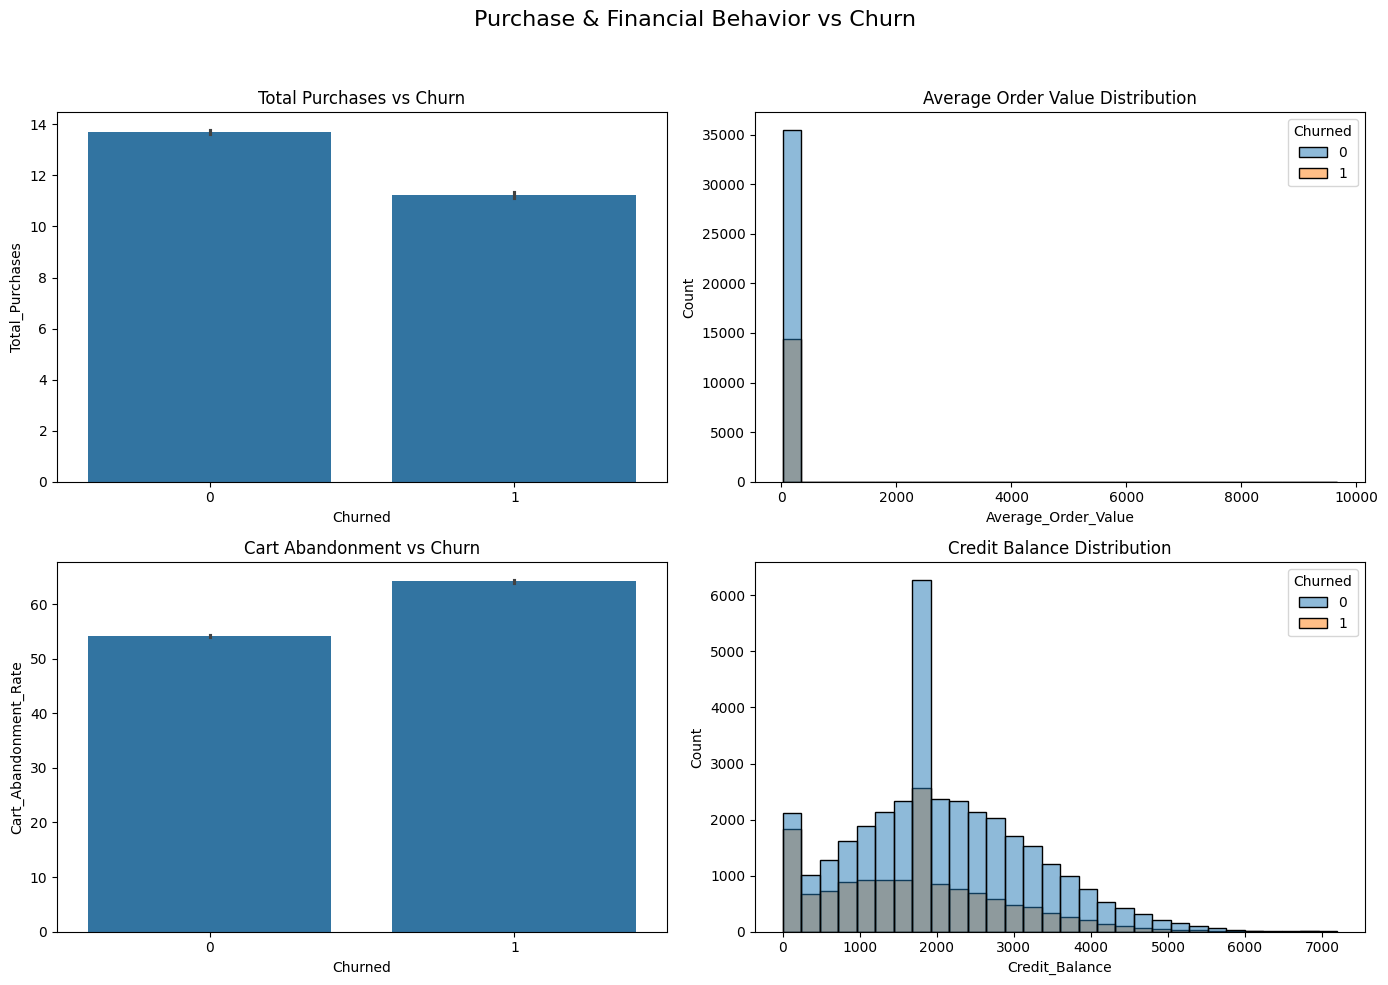

In [39]:
plt.figure(figsize=(14,10))
plt.suptitle("Purchase & Financial Behavior vs Churn", fontsize=16)

# Total Purchases
plt.subplot(2,2,1)
sns.barplot(x='Churned', y='Total_Purchases', data=df)
plt.title("Total Purchases vs Churn")

# Average Order Value
plt.subplot(2,2,2)
sns.histplot(data=df, x='Average_Order_Value', hue='Churned', bins=30)
plt.title("Average Order Value Distribution")

# Cart Abandonment
plt.subplot(2,2,3)
sns.barplot(x='Churned', y='Cart_Abandonment_Rate', data=df)
plt.title("Cart Abandonment vs Churn")

# Credit Balance
plt.subplot(2,2,4)
sns.histplot(data=df, x='Credit_Balance', hue='Churned', bins=30)
plt.title("Credit Balance Distribution")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

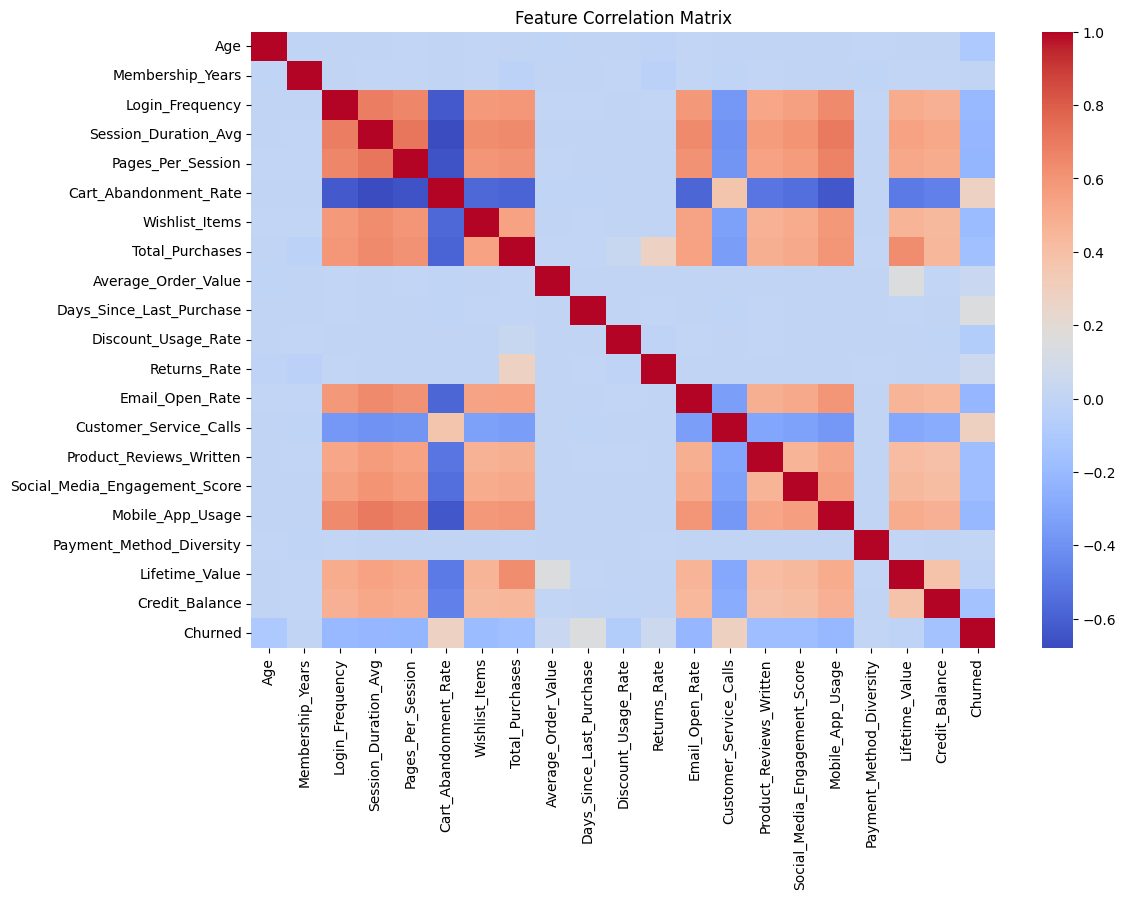

In [40]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Matrix")
plt.show()

In [41]:
X = df.drop('Churned', axis=1)
y = df['Churned']

In [42]:
X = pd.get_dummies(X, drop_first=True)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [46]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier()
}

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5]
}

grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid,
    cv=5,
    scoring={
        'accuracy':'accuracy',
        'precision':'precision',
        'recall':'recall',
        'f1':'f1',
        'roc_auc':'roc_auc'
    },
    refit='roc_auc',   # model selection based on ROC-AUC
    return_train_score=True
)

grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : th

In [48]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [49]:
print("Best ROC-AUC:", grid.best_score_)

Best ROC-AUC: 0.9275692323493534


In [50]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

results[['mean_test_accuracy',
         'mean_test_precision',
         'mean_test_recall',
         'mean_test_f1',
         'mean_test_roc_auc']]

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc
0,0.833809,0.954205,0.448205,0.609841,0.888835
1,0.876827,0.942024,0.612828,0.742550,0.912564
2,0.879755,0.949352,0.618181,0.748613,0.914709
3,0.902978,0.938680,0.711844,0.809639,0.921519
4,0.917718,0.932484,0.772099,0.844701,0.926233
5,0.920270,0.927975,0.785997,0.851061,0.927425
6,0.920220,0.920502,0.793335,0.852168,0.927345
7,0.919319,0.914452,0.796184,0.851213,0.927569


In [51]:
best_model = grid.best_estimator_
print(best_model)

GradientBoostingClassifier(max_depth=5, n_estimators=200)


In [52]:
y_pred = best_model.predict(X_test_scaled)


In [53]:
y_prob = best_model.predict_proba(X_test_scaled)[:,1]
y_prob

array([0.43091915, 0.0439365 , 0.39476148, ..., 0.92101631, 0.03610576,
       0.99422782], shape=(9990,))

In [54]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9222111890158786


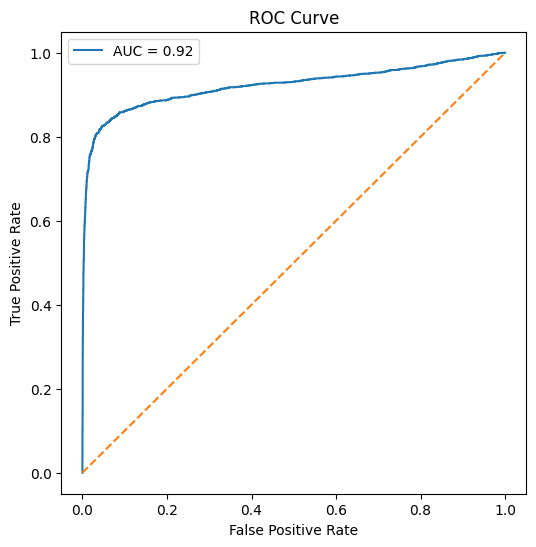

In [55]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

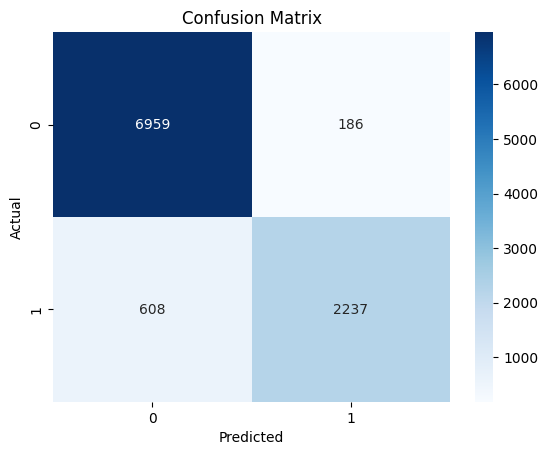

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7145
           1       0.92      0.79      0.85      2845

    accuracy                           0.92      9990
   macro avg       0.92      0.88      0.90      9990
weighted avg       0.92      0.92      0.92      9990



In [58]:
import pandas as pd

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

Lifetime_Value              0.242105
Cart_Abandonment_Rate       0.173610
Customer_Service_Calls      0.135639
Discount_Usage_Rate         0.116690
Days_Since_Last_Purchase    0.074988
Age                         0.048695
Email_Open_Rate             0.047323
Total_Purchases             0.045522
Session_Duration_Avg        0.021986
Returns_Rate                0.019688
dtype: float64

In [63]:
import pickle

feature_columns = X.columns

pickle.dump(feature_columns, open("feature_columns.pkl", "wb"))

In [64]:
import pickle

pickle.dump(best_model, open("churn_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))